# Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('drive')

Mounted at drive


In [2]:
!pip install resampy
!pip install -U librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import os
import json

from glob import glob
import pickle
import itertools
from PIL import Image
import IPython
from IPython.display import Audio
import librosa
import matplotlib.pyplot as plt
%matplotlib inline
import pickle

# 1. Combine RAVDESS & Crema data

In [ ]:
path_Ravdess = "drive/My Drive/Speech Emotion Recognition/data/RAVDESS/"
path_Crema   = "drive/My Drive/Speech Emotion Recognition/data/CREMA/"

### Load RAVDESS data

In [ ]:
# Load the RAVDESS data
files_Ravdess = os.listdir(path_Ravdess)

# Emotion label mapping
Ravdess_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad', '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'}

# Create a dataframe
data = []
for fil in files_Ravdess:
    parts = fil.split('-') # The 3rd element in parts represent the emotion labels
    cc = parts[2]          # Extract the 3rd element
    label_int = int(cc)    # Convert it to int
    label_str = Ravdess_map[cc]
    full_path = os.path.join(path_Ravdess, fil)
    data.append([full_path, label_int, label_str])

df_ravdess = pd.DataFrame(data, columns=['path', 'label_int', 'label_str'])
df_ravdess.head()

,path,label_int,label_str
0,drive/My Drive/Speech Emotion Recognition/data...,5,angry
1,drive/My Drive/Speech Emotion Recognition/data...,6,fearful
2,drive/My Drive/Speech Emotion Recognition/data...,1,neutral
3,drive/My Drive/Speech Emotion Recognition/data...,3,happy
4,drive/My Drive/Speech Emotion Recognition/data...,4,sad


In [ ]:
# Count the audio files in each label

cc_counts = df_ravdess['label_int'].value_counts().sort_index()

for cc in range(1, 9):
    emotion = df_ravdess[df_ravdess['label_int'] == cc]['label_str'].iloc[0]
    count = cc_counts.get(cc, 0)
    print(f'{cc:02d} - {emotion} - {count} files')

01 - neutral - 96 files
02 - calm - 192 files
03 - happy - 192 files
04 - sad - 192 files
05 - angry - 192 files
06 - fearful - 192 files
07 - disgust - 192 files
08 - surprised - 192 files


In [ ]:
df_ravdess.describe()

,label_int
count,1440.000000
mean,4.733333
std,2.175356
min,1.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,8.000000


In [ ]:
df_ravdess.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   path       1440 non-null   object
 1   label_int  1440 non-null   int64 
 2   label_str  1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [ ]:
df_ravdess.value_counts('label_str')

,count
label_str,
angry,192
calm,192
disgust,192
fearful,192
happy,192
sad,192
surprised,192
neutral,96


Clearly, the RAVDESS dataset is imbalanced.

### Load CREMA data

In [ ]:
files_Crema = os.listdir(path_Crema)

# Emotion label mapping
Crema_map = {'ANG':'angry', 'DIS':'disgust', 'FEA':'fearful', 'HAP':'happy', 'NEU':'neutral', 'SAD':'sad'}

# Collect data
data = []
for fil in files_Crema:
    parts = fil.split('_')
    CCC = parts[2]  # Extract the 3rd element in parts. It represent the emotion labels
    label_str2 = Crema_map[CCC]
    full_path = os.path.join(path_Crema, fil)
    data.append([full_path, CCC, label_str2])

# Create DataFrame
df_crema = pd.DataFrame(data, columns=['path', 'label_str1', 'label_str2'])
df_crema.head()

,path,label_str1,label_str2
0,drive/My Drive/Speech Emotion Recognition/data...,FEA,fearful
1,drive/My Drive/Speech Emotion Recognition/data...,NEU,neutral
2,drive/My Drive/Speech Emotion Recognition/data...,HAP,happy
3,drive/My Drive/Speech Emotion Recognition/data...,FEA,fearful
4,drive/My Drive/Speech Emotion Recognition/data...,HAP,happy


In [ ]:
df_crema.describe()

,path,label_str1,label_str2
count,5462,5462,5462
unique,5462,6,6
top,drive/My Drive/Speech Emotion Recognition/data...,ANG,angry
freq,1,934,934


In [ ]:
df_crema.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5462 entries, 0 to 5461
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   path        5462 non-null   object
 1   label_str1  5462 non-null   object
 2   label_str2  5462 non-null   object
dtypes: object(3)
memory usage: 128.1+ KB


In [ ]:
df_crema.value_counts('label_str2')

,count
label_str2,
angry,934
disgust,933
fearful,933
sad,933
happy,932
neutral,797


The CREMA dataset is also imbalanced.

*italicised text*# Creating a uniform dataset

In [ ]:
print(df_ravdess.columns)

Index(['path', 'label_int', 'label_str'], dtype='object')


In [ ]:
print(df_crema.columns)

Index(['path', 'label_str1', 'label_str2'], dtype='object')


### Make both the dataframes uniform

In [ ]:
df_ravdess.drop('label_int', axis=1, inplace=True)
print(df_ravdess.columns)

Index(['path', 'label_str'], dtype='object')


In [ ]:
df_crema = df_crema.rename(columns={'label_str2': 'label_str'})
df_crema.drop('label_str1', axis=1, inplace=True)
print(df_crema.columns)

Index(['path', 'label_str'], dtype='object')


In [ ]:
# Combine the dataframes
df_aud = pd.concat([df_ravdess, df_crema], axis = 0)
df_aud.shape

(6902, 2)

In [ ]:
df_aud.head()

,path,label_str
0,drive/My Drive/Speech Emotion Recognition/data...,angry
1,drive/My Drive/Speech Emotion Recognition/data...,fearful
2,drive/My Drive/Speech Emotion Recognition/data...,neutral
3,drive/My Drive/Speech Emotion Recognition/data...,happy
4,drive/My Drive/Speech Emotion Recognition/data...,sad


In [ ]:
df_aud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6902 entries, 0 to 5461
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   path       6902 non-null   object
 1   label_str  6902 non-null   object
dtypes: object(2)
memory usage: 161.8+ KB


In [ ]:
# Print the labels
print(df_aud['label_str'].unique())

['angry' 'fearful' 'neutral' 'happy' 'sad' 'disgust' 'surprised' 'calm']


In [ ]:
df_aud.value_counts('label_str')

,count
label_str,
angry,1126
disgust,1125
fearful,1125
sad,1125
happy,1124
neutral,893
calm,192
surprised,192


The combined dataset is imbalanced.

### Remove data that belongs to these labels

In [ ]:
remove_labels = ['disgust', 'fearful', 'surprised']
df_aud = df_aud[~df_aud['label_str'].isin(remove_labels)].reset_index(drop=True)

print(df_aud['label_str'].unique())

['angry' 'neutral' 'happy' 'sad' 'calm']


In [ ]:
df_aud.value_counts('label_str')

,count
label_str,
angry,1126
sad,1125
happy,1124
neutral,893
calm,192


### Combine data with labels 'calm' and 'neutral'

In [ ]:
df_aud['label_str'] = df_aud['label_str'].replace('calm', 'neutral')
print(df_aud['label_str'].unique())

['angry' 'neutral' 'happy' 'sad']


In [ ]:
df_aud.value_counts('label_str')

,count
label_str,
angry,1126
sad,1125
happy,1124
neutral,1085


### Truncate all datasets to match the shortest one

In [ ]:
df_aud['label_str'].value_counts().min()

1085

In [ ]:
# Get the minimum count in the unique labels
min_count = df_aud['label_str'].value_counts().min()

# Truncate each label/class to min_count randomly
df_aud_uniform = df_aud.groupby('label_str', group_keys=False).apply(lambda x: x.sample(n=min_count, random_state=42)).reset_index(drop=True)

df_aud_uniform.value_counts('label_str')

/tmp/ipykernel_588/2153219182.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_aud_uniform = df_aud.groupby('label_str', group_keys=False).apply(lambda x: x.sample(n=min_count, random_state=42)).reset_index(drop=True)


,count
label_str,
angry,1085
happy,1085
neutral,1085
sad,1085


In [ ]:
# Find the size of the smallest class to balance the dataset
min_count = df_aud['label_str'].value_counts().min()

# Downsample each class to match min_count and combine into a single balanced dataframe
dfs = []
for label in df_aud['label_str'].unique():
    subset = df_aud[df_aud['label_str'] == label].sample(n=min_count, random_state=42)
    dfs.append(subset)

# Shuffle the labelled dataset
df_aud_uniform = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)

df_aud_uniform.value_counts('label_str')

,count
label_str,
angry,1085
happy,1085
neutral,1085
sad,1085


In [ ]:
df_aud_uniform.head()

,path,label_str
0,drive/My Drive/Speech Emotion Recognition/data...,sad
1,drive/My Drive/Speech Emotion Recognition/data...,neutral
2,drive/My Drive/Speech Emotion Recognition/data...,happy
3,drive/My Drive/Speech Emotion Recognition/data...,angry
4,drive/My Drive/Speech Emotion Recognition/data...,neutral


In [ ]:
# df_aud_uniform2 = df_aud_uniform.sample(frac=1, random_state=42).reset_index(drop=True)
# df_aud_uniform2.head()

,path,label_str
0,drive/My Drive/State Shifter/proj6 - SER/Crema...,sad
1,drive/My Drive/State Shifter/proj6 - SER/Crema...,neutral
2,drive/My Drive/State Shifter/proj6 - SER/Crema...,happy
3,drive/My Drive/State Shifter/proj6 - SER/Crema...,angry
4,drive/My Drive/State Shifter/proj6 - SER/Ravde...,neutral


In [ ]:
df_aud_uniform.tail()

,path,label_str
4335,drive/My Drive/Speech Emotion Recognition/data...,sad
4336,drive/My Drive/Speech Emotion Recognition/data...,angry
4337,drive/My Drive/Speech Emotion Recognition/data...,happy
4338,drive/My Drive/Speech Emotion Recognition/data...,sad
4339,drive/My Drive/Speech Emotion Recognition/data...,angry


In [ ]:
df_aud_uniform.shape

(4340, 2)

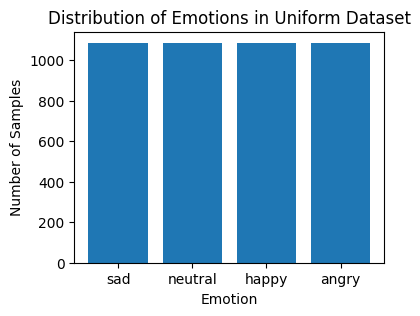

In [ ]:
label_counts = df_aud_uniform['label_str'].value_counts()

labels = label_counts.index
counts = label_counts.values

plt.figure(figsize=(4, 3))
plt.bar(labels, counts)
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.title('Distribution of Emotions in Uniform Dataset')
plt.show()

Uniform, well-shuffled data is now ready.

In [ ]:
# Save the dataframe
df_aud_uniform.to_csv('drive/My Drive/Speech Emotion Recognition/data/RavdessCrema4Labels.csv')

# 2. Data loading

In [4]:
df_aud_uniform = pd.read_csv('drive/My Drive/Speech Emotion Recognition/data/RavdessCrema4Labels.csv')
print(df_aud_uniform.shape)
df_aud_uniform.head()

(4340, 3)


,Unnamed: 0,path,label_str
0,0,drive/My Drive/Speech Emotion Recognition/data...,sad
1,1,drive/My Drive/Speech Emotion Recognition/data...,neutral
2,2,drive/My Drive/Speech Emotion Recognition/data...,happy
3,3,drive/My Drive/Speech Emotion Recognition/data...,angry
4,4,drive/My Drive/Speech Emotion Recognition/data...,neutral


In [5]:
df_aud_uniform = df_aud_uniform.drop('Unnamed: 0', axis=1)
print(df_aud_uniform.shape, df_aud_uniform.columns)

(4340, 2) Index(['path', 'label_str'], dtype='object')


Index(['sad', 'neutral', 'happy', 'angry'], dtype='object', name='label_str') [1085 1085 1085 1085]


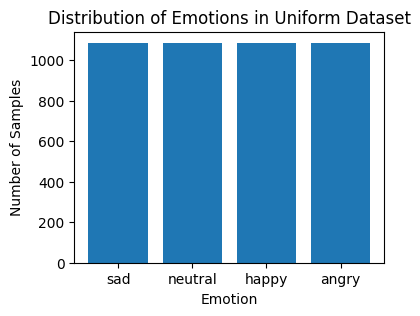

In [6]:
# Visualise the data distribution across labels
label_counts = df_aud_uniform['label_str'].value_counts()
labels = label_counts.index
counts = label_counts.values
print(labels, counts)

plt.figure(figsize=(4, 3))
plt.bar(labels, counts)
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.title('Distribution of Emotions in Uniform Dataset')
plt.show()

del label_counts, labels, counts

### Examples of amplitudes and spectrogram of happy, sad, angry, neutral audio

In [7]:
df_aud_uniform.head()

,path,label_str
0,drive/My Drive/Speech Emotion Recognition/data...,sad
1,drive/My Drive/Speech Emotion Recognition/data...,neutral
2,drive/My Drive/Speech Emotion Recognition/data...,happy
3,drive/My Drive/Speech Emotion Recognition/data...,angry
4,drive/My Drive/Speech Emotion Recognition/data...,neutral


In [8]:
def create_waveplot(data, sr, e):
    plt.figure(figsize=(12, 3))
    plt.title(f'Waveplot for audio with {e} emotion', size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.show()

def create_spectrogram(data, sr, e):
    X = librosa.stft(data) # short term fourier transform
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title(f'Spectrogram for audio with {e} emotion', size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    # librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar()

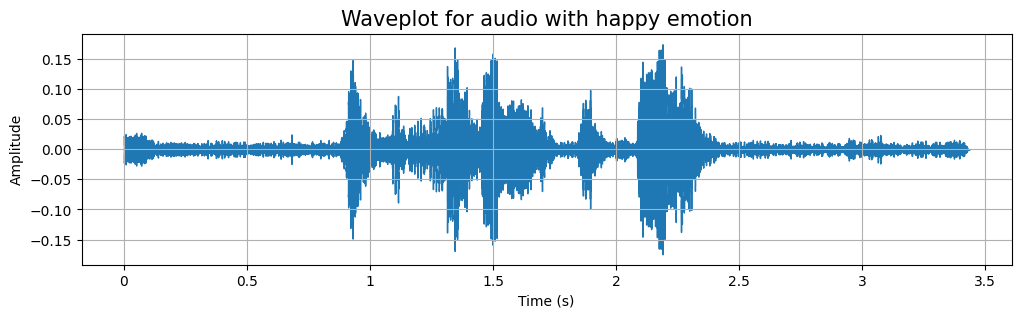

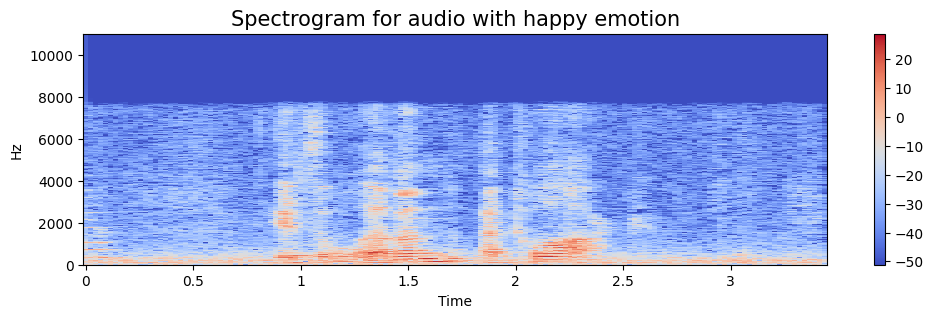

In [9]:
emotion = df_aud_uniform.iloc[2]['label_str']
path    = df_aud_uniform.iloc[2]['path']
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

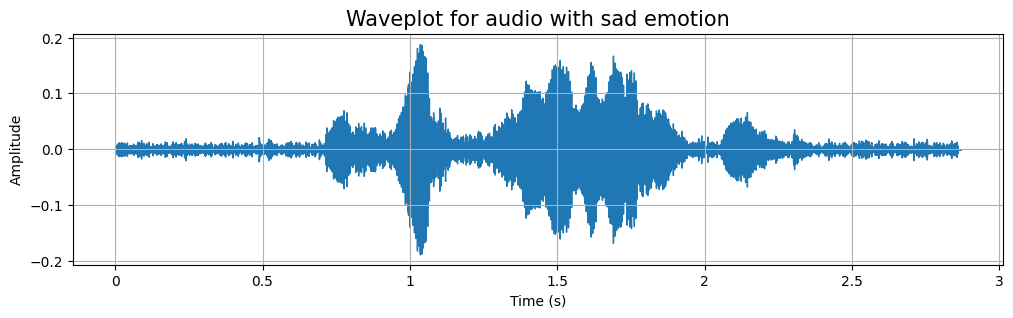

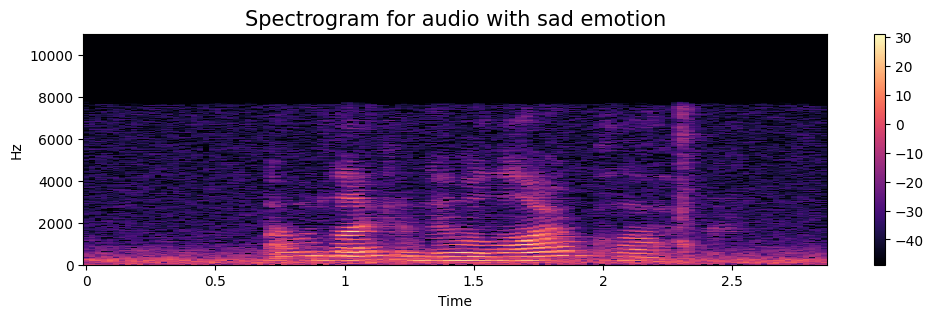

In [10]:
emotion = df_aud_uniform.iloc[0]['label_str']
path    = df_aud_uniform.iloc[0]['path']
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

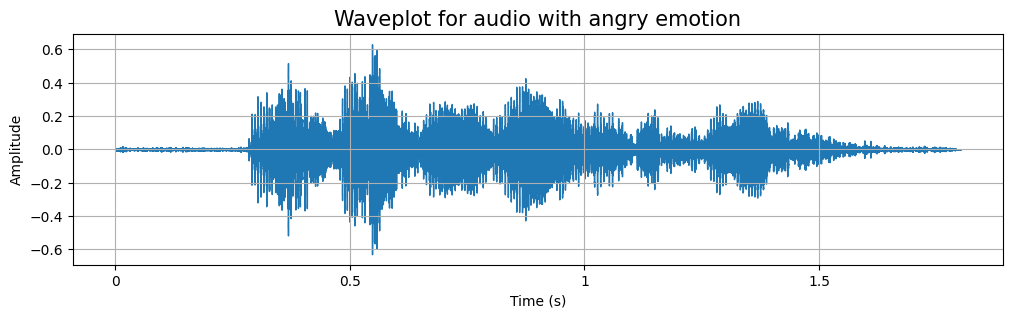

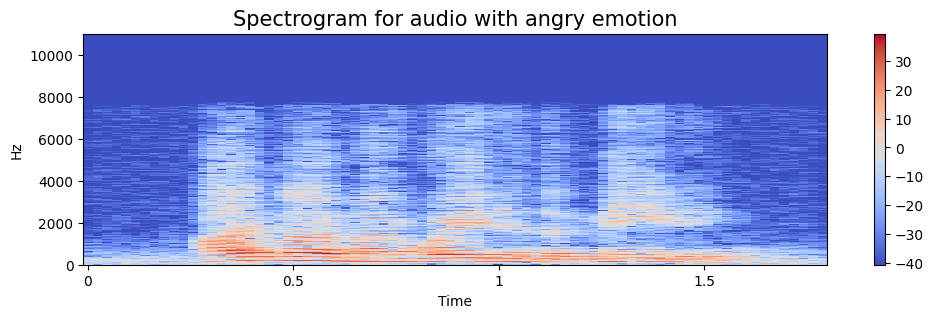

In [11]:
emotion = df_aud_uniform.iloc[3]['label_str']
path    = df_aud_uniform.iloc[3]['path']
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

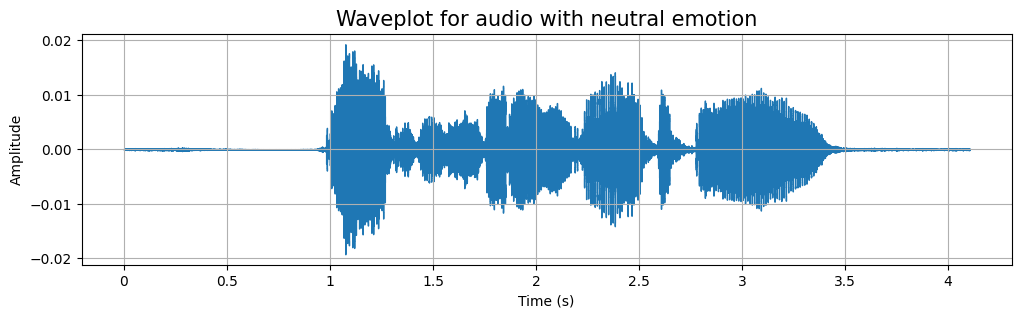

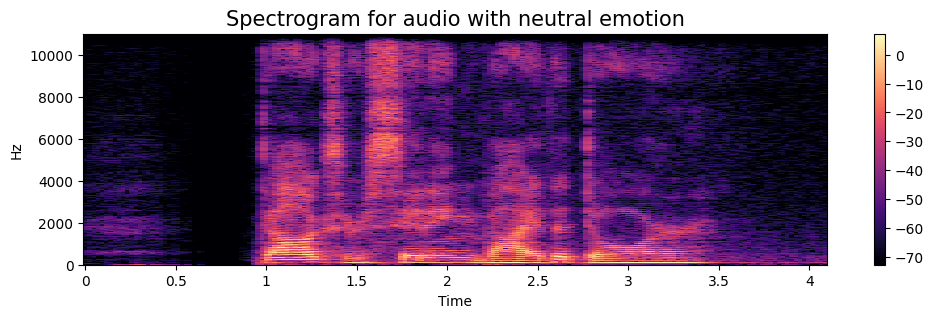

In [12]:
emotion = df_aud_uniform.iloc[4]['label_str']
path    = df_aud_uniform.iloc[4]['path']
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

# 3. Data Augmentation

In [13]:
# Add noise to signal
def add_noise(signal):
    noise_amp = 0.035*np.random.uniform()*np.amax(signal)
    signal = signal + noise_amp*np.random.normal(size=signal.shape[0])
    return signal

# Change the speed/duration of the audio without changing the pitch
def stretch_audio(signal, sampling_rate, rate=0.8):
    return librosa.effects.time_stretch(y=signal, rate=rate)

# Shift the audio signal forward or backward along time
def shift_audio(signal):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(signal, shift_range)

# Change the pitch
def change_pitch(signal, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(signal, sr=sampling_rate, n_steps=4)


In [14]:
# Load a sample data/audio signal
emotion = df_aud_uniform.iloc[2]['label_str']
path    = df_aud_uniform.iloc[2]['path']
data, sampling_rate = librosa.load(path)

# Original audio
print(emotion)
Audio(data, rate=sampling_rate)

happy


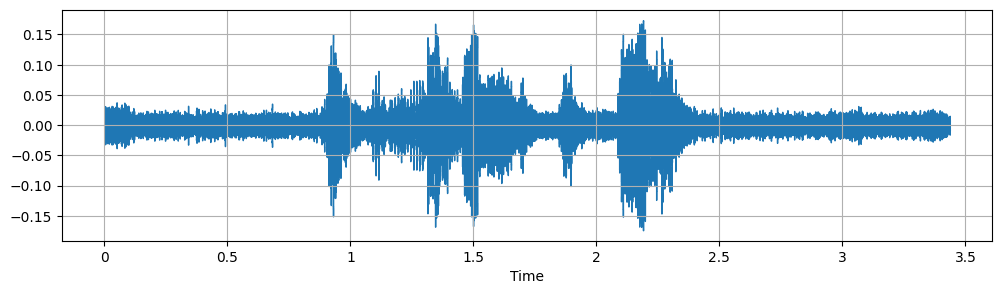

In [15]:
# Add noise
x = add_noise(data)
plt.figure(figsize=(12,3))
librosa.display.waveshow(y=x, sr=sampling_rate)
Audio(x, rate=sampling_rate)
plt.grid()

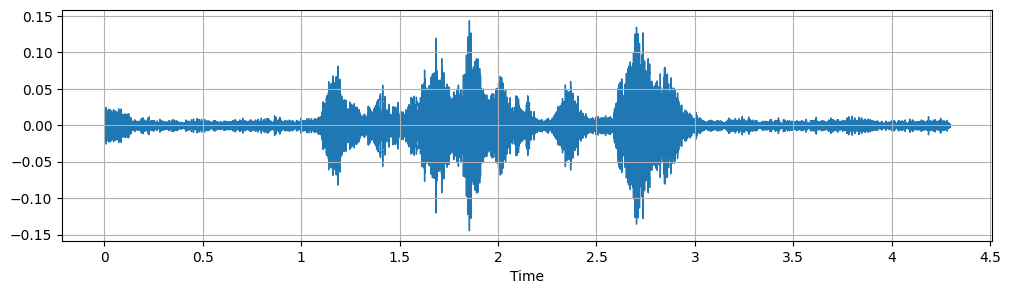

In [16]:
# Stretch audio
x = stretch_audio(data, sampling_rate)
plt.figure(figsize=(12,3))
librosa.display.waveshow(y=x, sr=sampling_rate)
Audio(x, rate=sampling_rate)
plt.grid()

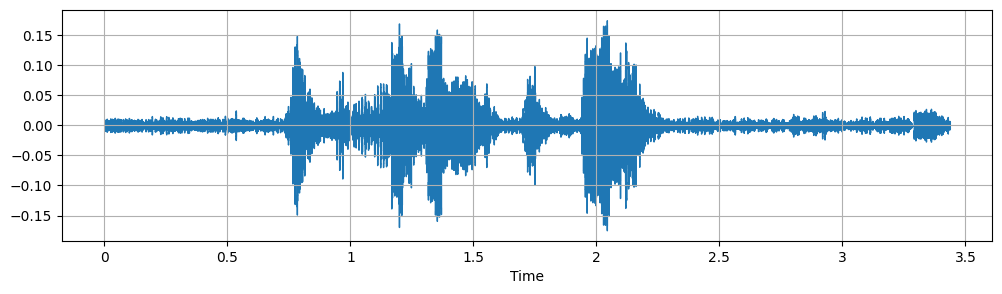

In [17]:
# Shift audio in time
x = shift_audio(data)
plt.figure(figsize=(12,3))
librosa.display.waveshow(y=x, sr=sampling_rate)
Audio(x, rate=sampling_rate)
plt.grid()

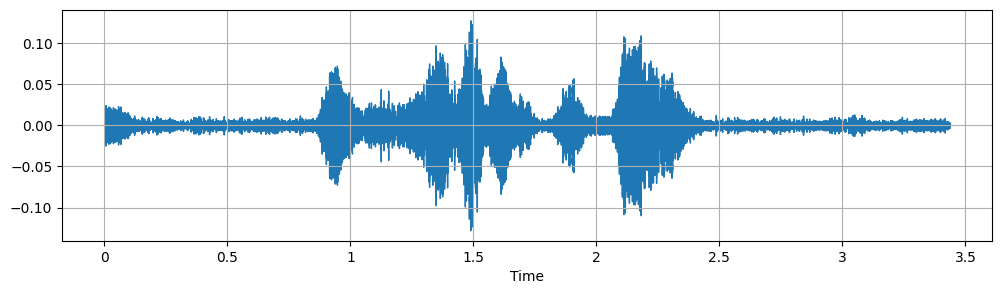

In [18]:
# Change pitch
x = change_pitch(data, sampling_rate) # Add sampling_rate here
plt.figure(figsize=(12,3))
librosa.display.waveshow(y=x, sr=sampling_rate)
Audio(x, rate=sampling_rate)
plt.grid()

To have a diverse dataset, you can augment the audio files and include them in your dataset.

# 4. Data pre-processing

### 4.1 Peak Normalisation

Peak normalization scales audio track amplitudes to the range $[-1, 1]$. This standardizes inputs to ensure numerical stability.

In [19]:
# Peak normalisation

def preprocessing_y(i):
    top_db=20
    path    = df_aud_uniform.iloc[i]['path']
    y, sr = librosa.load(path, sr=16000)
    y_trimmed, index = librosa.effects.trim(y, top_db=top_db)
    y_normz = y_trimmed / np.max(np.abs(y_trimmed))
    return y_normz

y_lens, y_all = [], []

for i in range(len(df_aud_uniform)):
    y_normz = preprocessing_y(i)
    y_lens.append(len(y_normz))
    y_all.append(y_normz)

print(f"Original audio, min & max audio lengths: {min(y_lens)}, {max(y_lens)}")

Original audio, min & max audio lengths: 9728, 80080


### 4.2 Zero padding

Zero padding is done to have all the audio tracks in same length.

In [20]:
# Zero padding - y_all
max_len = max(len(lst) for lst in y_all)
padded_y_all = [np.pad(arr, (0, max_len - len(arr)), mode='constant') for arr in y_all]
nppadded_y_all = np.vstack(padded_y_all)

print(nppadded_y_all.shape)
print(f"Lengths of a list before zero padding: {len(y_all[0])}")
print(f"Lengths of a list after zero padding: {len(padded_y_all[0])}")
del y_all, padded_y_all

(4340, 80080)
Lengths of a list before zero padding: 41472
Lengths of a list after zero padding: 80080


# 5. Feature Extraction - 86 audio features

In [21]:
def entropy_of_energy(energy_frames, eps=1e-6):
    prob_energy = energy_frames / np.sum(energy_frames + eps)
    entropy = -np.sum(prob_energy * np.log2(prob_energy + eps))
    return entropy

def spectral_flux(S):
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2)) / S.shape[1]
    return flux

def FeatureExtraction2(data, sample_rate=16000):
    result = np.array([])

    # --- Temporal Features ---
    # 1. Zero Crossing Rate
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result = np.hstack((result, zcr))

    # 2. RMS Energy
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms))

    # 3. Entropy of Energy
    energy_frames = librosa.feature.rms(y=data).flatten()
    entropy = entropy_of_energy(energy_frames)
    result = np.hstack((result, entropy))

    # --- Harmonic Features ---
    # 4. Chroma STFT (12)
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft))

    # --- Prosodic Features ---
    # 5. MFCCs (13) + Delta (13) + Delta-Delta (13)
    mfcc = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=13)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    delta_mfcc = librosa.feature.delta(mfcc)
    delta_mfcc_mean = np.mean(delta_mfcc.T, axis=0)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    delta2_mfcc_mean = np.mean(delta2_mfcc.T, axis=0)
    result = np.hstack((result, mfcc_mean, delta_mfcc_mean, delta2_mfcc_mean))

    # 6. Mel Spectrogram (20)
    mel = librosa.feature.melspectrogram(y=data, sr=sample_rate, n_mels=20)
    mel_mean = np.mean(mel.T, axis=0)
    result = np.hstack((result, mel_mean))

    # --- Spectral Features ---
    # 7. Spectral Centroid
    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, spec_centroid))

    # 8. Spectral Rolloff
    spec_rolloff = np.mean(librosa.feature.spectral_rolloff(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, spec_rolloff))

    # 9. Spectral Bandwidth
    spec_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, spec_bandwidth))

    # 10. Spectral Contrast (7)
    spec_contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, spec_contrast))

    # 11. Spectral Flatness
    flatness = np.mean(librosa.feature.spectral_flatness(y=data).T, axis=0)
    result = np.hstack((result, flatness))

    # 12. Spectral Flux
    S = librosa.stft(data)
    flux = spectral_flux(np.abs(S))
    result = np.hstack((result, flux))

    return result

In [22]:
# Extract the audio features
features_y_all = np.vstack([FeatureExtraction2(audio) for audio in nppadded_y_all])
print(features_y_all.shape)

(4340, 86)


In [ ]:
col_names = [
    # Temporal
    "zcr",                         # 1
    "rms_energy",                  # 2
    "entropy_of_energy",           # 3

    # Harmonic
    *[f"chroma_stft_{i+1}" for i in range(12)],  # 4–15

    # Prosodic - MFCCs and deltas
    *[f"mfcc_{i+1}" for i in range(13)],         # 16–28
    *[f"delta_mfcc_{i+1}" for i in range(13)],   # 29–41
    *[f"delta2_mfcc_{i+1}" for i in range(13)],  # 42–54

    # Prosodic - Mel Spectrogram
    *[f"mel_spectrogram_{i+1}" for i in range(20)],  # 55–74

    # Spectral
    "spectral_centroid",           # 75
    "spectral_rolloff",            # 76
    "spectral_bandwidth",          # 77
    *[f"spectral_contrast_{i+1}" for i in range(7)],  # 78–84
    "spectral_flatness",           # 85
    "spectral_flux"                # 86
]

In [24]:
# Save the extracted features

col_names = [
    # Temporal
    "zcr",                         # 1
    "rms_energy",                  # 2
    "entropy_of_energy",           # 3

    # Harmonic
    *[f"chroma_stft_{i+1}" for i in range(12)],  # 4–15

    # Prosodic - MFCCs and deltas
    *[f"mfcc_{i+1}" for i in range(13)],         # 16–28
    *[f"delta_mfcc_{i+1}" for i in range(13)],   # 29–41
    *[f"delta2_mfcc_{i+1}" for i in range(13)],  # 42–54

    # Prosodic - Mel Spectrogram
    *[f"mel_spectrogram_{i+1}" for i in range(20)],  # 55–74

    # Spectral
    "spectral_centroid",           # 75
    "spectral_rolloff",            # 76
    "spectral_bandwidth",          # 77
    *[f"spectral_contrast_{i+1}" for i in range(7)],  # 78–84
    "spectral_flatness",           # 85
    "spectral_flux"                # 86
]

df_y_features86 = pd.DataFrame(features_y_all, columns=col_names)
df_y_features86['label_str'] = df_aud_uniform['label_str'].values

df_y_features86.to_csv('drive/My Drive/Speech Emotion Recognition/Feature Extraction/Features86Y.csv')

df_y_features86.head()

,zcr,rms_energy,entropy_of_energy,chroma_stft_1,chroma_stft_2,chroma_stft_3,chroma_stft_4,chroma_stft_5,chroma_stft_6,chroma_stft_7,...,spectral_contrast_1,spectral_contrast_2,spectral_contrast_3,spectral_contrast_4,spectral_contrast_5,spectral_contrast_6,spectral_contrast_7,spectral_flatness,spectral_flux,label_str
0,0.033648,0.056538,5.878391,0.252604,0.321187,0.269960,0.258023,0.261429,0.309736,0.344913,...,18.081081,18.773091,20.681076,20.069512,18.824755,18.219602,17.329894,0.476718,4.025229,sad
1,0.037072,0.052796,5.923903,0.340793,0.372256,0.382875,0.338756,0.315273,0.302843,0.366644,...,17.442136,17.519435,18.955904,18.947792,18.337109,18.134669,17.270467,0.466255,4.017232,neutral
2,0.046760,0.060077,6.104278,0.398048,0.408765,0.415193,0.427376,0.443569,0.420900,0.426906,...,15.082894,15.031562,17.074540,16.285341,16.701377,16.755661,15.121865,0.380671,4.135634,happy
3,0.016972,0.043693,5.307026,0.147055,0.164995,0.163687,0.174945,0.179817,0.138748,0.112265,...,20.111721,19.210239,20.264948,19.540943,19.234331,19.096589,18.253717,0.720665,3.633934,angry
4,0.055070,0.086008,6.193079,0.269528,0.317289,0.242114,0.260210,0.285733,0.302225,0.324385,...,21.636049,15.746497,17.032371,16.281836,16.775823,16.398765,32.554090,0.498595,4.198176,neutral


In [32]:
df_y_features86.columns

Index(['zcr', 'rms_energy', 'entropy_of_energy', 'chroma_stft_1',
       'chroma_stft_2', 'chroma_stft_3', 'chroma_stft_4', 'chroma_stft_5',
       'chroma_stft_6', 'chroma_stft_7', 'chroma_stft_8', 'chroma_stft_9',
       'chroma_stft_10', 'chroma_stft_11', 'chroma_stft_12', 'mfcc_1',
       'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8',
       'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'delta_mfcc_1',
       'delta_mfcc_2', 'delta_mfcc_3', 'delta_mfcc_4', 'delta_mfcc_5',
       'delta_mfcc_6', 'delta_mfcc_7', 'delta_mfcc_8', 'delta_mfcc_9',
       'delta_mfcc_10', 'delta_mfcc_11', 'delta_mfcc_12', 'delta_mfcc_13',
       'delta2_mfcc_1', 'delta2_mfcc_2', 'delta2_mfcc_3', 'delta2_mfcc_4',
       'delta2_mfcc_5', 'delta2_mfcc_6', 'delta2_mfcc_7', 'delta2_mfcc_8',
       'delta2_mfcc_9', 'delta2_mfcc_10', 'delta2_mfcc_11', 'delta2_mfcc_12',
       'delta2_mfcc_13', 'mel_spectrogram_1', 'mel_spectrogram_2',
       'mel_spectrogram_3', 'mel_spectrogram_4'

In [33]:
df_y_features86.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 87 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   zcr                  4340 non-null   float64
 1   rms_energy           4340 non-null   float64
 2   entropy_of_energy    4340 non-null   float64
 3   chroma_stft_1        4340 non-null   float64
 4   chroma_stft_2        4340 non-null   float64
 5   chroma_stft_3        4340 non-null   float64
 6   chroma_stft_4        4340 non-null   float64
 7   chroma_stft_5        4340 non-null   float64
 8   chroma_stft_6        4340 non-null   float64
 9   chroma_stft_7        4340 non-null   float64
 10  chroma_stft_8        4340 non-null   float64
 11  chroma_stft_9        4340 non-null   float64
 12  chroma_stft_10       4340 non-null   float64
 13  chroma_stft_11       4340 non-null   float64
 14  chroma_stft_12       4340 non-null   float64
 15  mfcc_1               4340 non-null   f

In [34]:
df_y_features86.value_counts('label_str')

,count
label_str,
angry,1085
happy,1085
neutral,1085
sad,1085


### Visualise a sample Mel spectrogram (THIS CAN BE SKIPPED)

In [30]:
df_aud_uniform2 = pd.read_csv('drive/My Drive/Speech Emotion Recognition/data/RavdessCrema4Labels.csv')

i=200  # index of the audio track you want to visualise

path    = df_aud_uniform2.iloc[i]['path']
emo = df_aud_uniform2.iloc[i]['label_str']
y, sr = librosa.load(path, sr=16000)
print(f"file: {path}, emotion: {emo},\n y.shape: {y.shape}, sr: {sr}")
Audio(y, rate=sr)

file: drive/My Drive/Speech Emotion Recognition/data/CREMA/1030_TAI_ANG_XX.wav, emotion: angry,
 y.shape: (49116,), sr: 16000


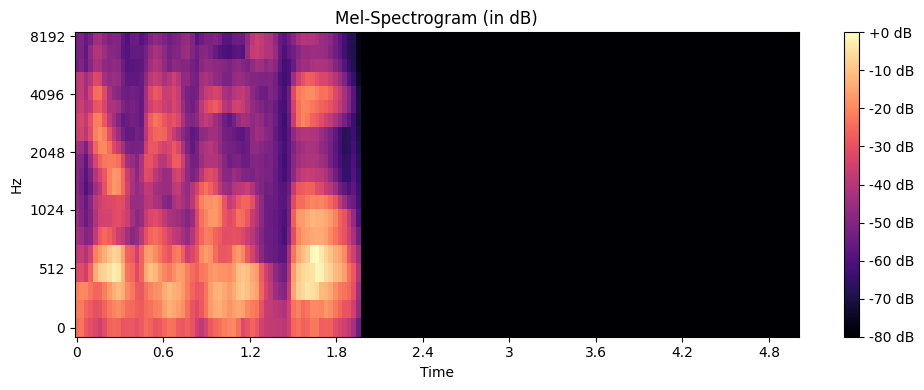

file: drive/My Drive/Speech Emotion Recognition/data/CREMA/1030_TAI_ANG_XX.wav, emotion: angry,
 original shape: (49116,), pre-processed shape:(80080,), sr: 16000


In [31]:
# Peak normalization to [-1, 1]
top_db=20
y_trimmed, index = librosa.effects.trim(y, top_db=top_db)
y_normz = y_trimmed / np.max(np.abs(y_trimmed))

# Zero padding
max_len1 = 80080 # 100100
y0 = np.pad(y_normz, (0, max_len1 - len(y_normz)), mode='constant')

# Compute Mel-Spectrogram
sample_rate = 16000
mel = librosa.feature.melspectrogram(y=y0, sr=sample_rate, n_mels=20)

# Convert to decibels
mel_db = librosa.power_to_db(mel, ref=np.max)

# Plot
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db,
                         sr=sample_rate,
                         x_axis='time',
                         y_axis='mel',
                         cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram (in dB)')
plt.tight_layout()
plt.show()

print(f"file: {path}, emotion: {emo},\n original shape: {y.shape}, pre-processed shape:{y0.shape}, sr: {sr}")

# 6. Features standardisation

In [35]:
# Load the features
df_y_features86 = pd.read_csv('drive/My Drive/Speech Emotion Recognition/Feature Extraction/Features86Y.csv')
df_y_features86 = df_y_features86.drop('Unnamed: 0', axis=1)
df_y_features86.shape

(4340, 87)

In [36]:
df_y_features86.columns

Index(['zcr', 'rms_energy', 'entropy_of_energy', 'chroma_stft_1',
       'chroma_stft_2', 'chroma_stft_3', 'chroma_stft_4', 'chroma_stft_5',
       'chroma_stft_6', 'chroma_stft_7', 'chroma_stft_8', 'chroma_stft_9',
       'chroma_stft_10', 'chroma_stft_11', 'chroma_stft_12', 'mfcc_1',
       'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8',
       'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'delta_mfcc_1',
       'delta_mfcc_2', 'delta_mfcc_3', 'delta_mfcc_4', 'delta_mfcc_5',
       'delta_mfcc_6', 'delta_mfcc_7', 'delta_mfcc_8', 'delta_mfcc_9',
       'delta_mfcc_10', 'delta_mfcc_11', 'delta_mfcc_12', 'delta_mfcc_13',
       'delta2_mfcc_1', 'delta2_mfcc_2', 'delta2_mfcc_3', 'delta2_mfcc_4',
       'delta2_mfcc_5', 'delta2_mfcc_6', 'delta2_mfcc_7', 'delta2_mfcc_8',
       'delta2_mfcc_9', 'delta2_mfcc_10', 'delta2_mfcc_11', 'delta2_mfcc_12',
       'delta2_mfcc_13', 'mel_spectrogram_1', 'mel_spectrogram_2',
       'mel_spectrogram_3', 'mel_spectrogram_4'

### 6.1 Standard scaler

In [37]:
from sklearn.preprocessing import StandardScaler

X = df_y_features86.iloc[:, :-1].values  # 86 features
y = df_y_features86.iloc[:, -1].values   # labels

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape, y.shape)

(4340, 86) (4340,)


### 6.2 Train-validate-test split

In [40]:
from sklearn.model_selection import train_test_split

# First split: Train (60%) + Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.4, stratify=y, random_state=42)

# Second split: Validation (20%) + Test (20%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [41]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(2604, 86) (2604,)
(868, 86) (868,)
(868, 86) (868,)


### 6.3 Encoding

In [42]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate, Reshape, Conv1D, MaxPooling1D, Bidirectional, LSTM, Flatten
import tensorflow as tf

In [43]:
# Label encoder
le = LabelEncoder()

# One-hot encoding of features
y_train_enc = to_categorical(le.fit_transform(y_train))
y_val_enc = to_categorical(le.transform(y_val))
y_test_enc = to_categorical(le.transform(y_test))

In [44]:
# Separate the features to 3 branches (time-domain, frequency-domain, spectral features), so that the model can learn them separately

temporal_idx = list(range(0, 3))    # zcr, rms, entropy
mfcc_idx = list(range(3, 42))       # mfcc + delta + delta2
spectral_idx = list(range(42, 86))  # spectral features

# Split feature branches
def split_branch(X, indices):
    return X[:, indices]

X_train_temporal = split_branch(X_train, temporal_idx)
X_val_temporal = split_branch(X_val, temporal_idx)
X_test_temporal = split_branch(X_test, temporal_idx)

X_train_mfcc = split_branch(X_train, mfcc_idx)
X_val_mfcc = split_branch(X_val, mfcc_idx)
X_test_mfcc = split_branch(X_test, mfcc_idx)

X_train_spectral = split_branch(X_train, spectral_idx)
X_val_spectral = split_branch(X_val, spectral_idx)
X_test_spectral = split_branch(X_test, spectral_idx)

In [45]:
print(X_train_temporal.shape, X_train_mfcc.shape, X_train_spectral.shape)
print(X_val_temporal.shape, X_val_mfcc.shape, X_val_spectral.shape)
print(X_test_temporal.shape, X_test_mfcc.shape, X_test_spectral.shape)

(2604, 3) (2604, 39) (2604, 44)
(868, 3) (868, 39) (868, 44)
(868, 3) (868, 39) (868, 44)


# 7. Neural network model

In [47]:
from tensorflow.keras.layers import LSTM, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [48]:
# Define inputs
input_temporal = Input(shape=(len(temporal_idx),), name='temporal_input')
input_mfcc = Input(shape=(len(mfcc_idx),), name='mfcc_input')
input_spectral = Input(shape=(len(spectral_idx),), name='spectral_input')

# Temporal branch
x_temp = Dense(32, activation='relu')(input_temporal)
x_temp = BatchNormalization()(x_temp)
x_temp = Dropout(0.2)(x_temp)

# MFCC branch (CNN only, no BiLSTM)
x_mfcc = Reshape((len(mfcc_idx), 1))(input_mfcc)
x_mfcc = Conv1D(64, kernel_size=3, activation='relu', padding='same')(x_mfcc)
x_mfcc = BatchNormalization()(x_mfcc)
x_mfcc = Dropout(0.3)(x_mfcc)
x_mfcc = Bidirectional(LSTM(32))(x_mfcc)

# Spectral branch
x_spec = Dense(32, activation='relu')(input_spectral)
x_spec = BatchNormalization()(x_spec)
x_spec = Dropout(0.2)(x_spec)

# Concatenate all
x = Concatenate()([x_temp, x_mfcc, x_spec])
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=[input_temporal, input_mfcc, input_spectral], outputs=output)

# Compile with categorical crossentropy
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping & learning rate scheduler
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=1)

# Train
history = model.fit(
    [X_train_temporal, X_train_mfcc, X_train_spectral], y_train_enc,
    validation_data=([X_val_temporal, X_val_mfcc, X_val_spectral], y_val_enc),
    epochs=70,
    batch_size=32,  # smaller batch helps generalization
    callbacks=[early_stop, lr_schedule],
    verbose=1
)

# Evaluate
train_acc = model.evaluate([X_train_temporal, X_train_mfcc, X_train_spectral], y_train_enc, verbose=0)[1]
val_acc = model.evaluate([X_val_temporal, X_val_mfcc, X_val_spectral], y_val_enc, verbose=0)[1]
test_acc = model.evaluate([X_test_temporal, X_test_mfcc, X_test_spectral], y_test_enc, verbose=0)[1]

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Epoch 1/70
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.4213 - loss: 1.4981 - val_accuracy: 0.4839 - val_loss: 1.1343 - learning_rate: 0.0010
Epoch 2/70
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4854 - loss: 1.2237 - val_accuracy: 0.5276 - val_loss: 1.0660 - learning_rate: 0.0010
Epoch 3/70
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5127 - loss: 1.1403 - val_accuracy: 0.5242 - val_loss: 1.0145 - learning_rate: 0.0010
Epoch 4/70
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5384 - loss: 1.0744 - val_accuracy: 0.5484 - val_loss: 0.9819 - learning_rate: 0.0010
Epoch 5/70
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5438 - loss: 1.0260 - val_accuracy: 0.5507 - val_loss: 0.9636 - learning_rate: 0.0010
Epoch 6/70
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5664 - loss: 0.9892 - val_accuracy: 0.5565 - val_loss: 0.9590 - learning_rate: 0.0010
Epoch 7/70
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5787 - loss: 0.9682 - val_ac

In [50]:
# Test predict
y_test_pred_prob = model.predict([X_test_temporal, X_test_mfcc, X_test_spectral])
y_test_pred = np.argmax(y_test_pred_prob, axis=1)
y_test_true = np.argmax(y_test_enc, axis=1)

# Decode using label encoder
y_labels = le.classes_
y_labels

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


array(['angry', 'happy', 'neutral', 'sad'], dtype=object)

In [51]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

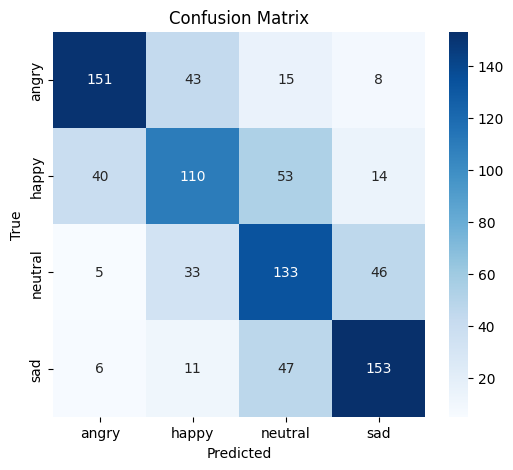


Classification Report:
              precision    recall  f1-score   support

       angry       0.75      0.70      0.72       217
       happy       0.56      0.51      0.53       217
     neutral       0.54      0.61      0.57       217
         sad       0.69      0.71      0.70       217

    accuracy                           0.63       868
   macro avg       0.63      0.63      0.63       868
weighted avg       0.63      0.63      0.63       868



In [52]:
cm = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_true, y_test_pred, target_names=le.classes_))

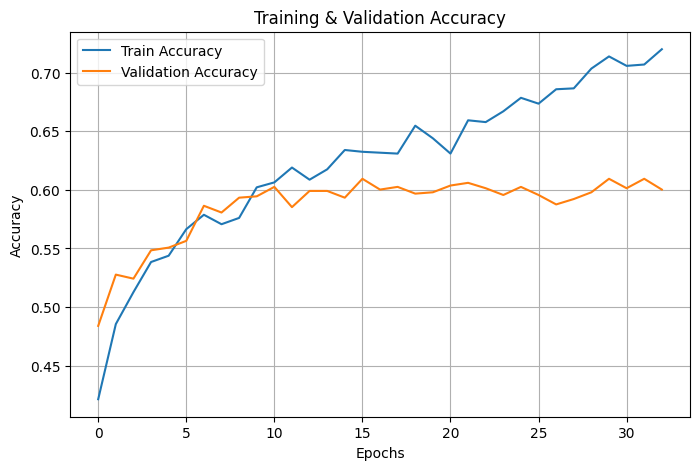

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
# Save the model
model_save_path = 'drive/My Drive/Speech Emotion Recognition/models/ser_model.h5'
model_save_path = 'drive/My Drive/Speech Emotion Recognition/models/ser_model.keras'
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
model.save(model_save_path)

# Save the scaler
scaler_save_path = 'drive/My Drive/Speech Emotion Recognition/models/ser_scaler.pkl'

with open(scaler_save_path, 'wb') as f:
    pickle.dump(scaler, f)

# Save the label encoder
le_save_path = 'drive/My Drive/Speech Emotion Recognition/models/ser_labelencoder.pkl'

with open(le_save_path, 'wb') as f:
    pickle.dump(le, f)

# 8. SUMMARY - Test the SER model on a single audio file

In [4]:
# Pick a random audio file name from the csv file of well-processed file names

df_aud_uniform2 = pd.read_csv('drive/My Drive/Speech Emotion Recognition/data/RavdessCrema4Labels.csv')
df_aud_uniform2 = df_aud_uniform2.drop('Unnamed: 0', axis=1)
print(f"Uniform dataset of audio file paths & emotion labels: {df_aud_uniform2.shape}")

# Select a random audio file
idx = 250
audio_path1 = df_aud_uniform2.loc[idx, 'path']
label1 = df_aud_uniform2.loc[idx, 'label_str']
print(f"File path: {audio_path1}, emotion: {label1}")
del df_aud_uniform2

Uniform dataset of audio file paths & emotion labels: (4340, 2)
File path: drive/My Drive/Speech Emotion Recognition/data/CREMA/1009_TSI_SAD_XX.wav, emotion: sad


In [5]:
# Play the adio
y, sr = librosa.load(audio_path1, sr=16000)
Audio(y, rate=sr)

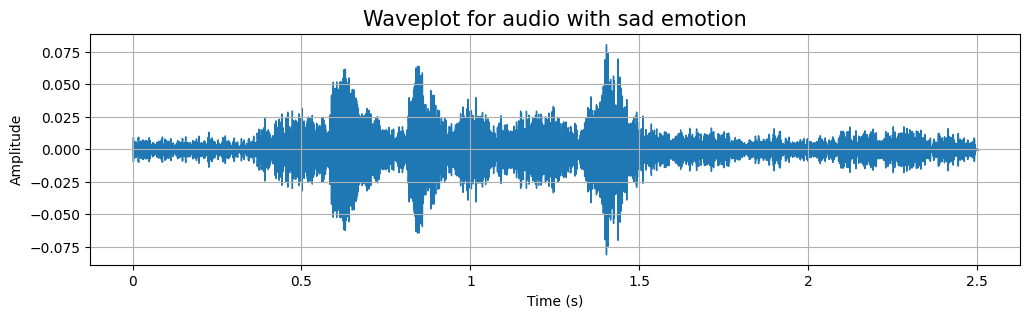

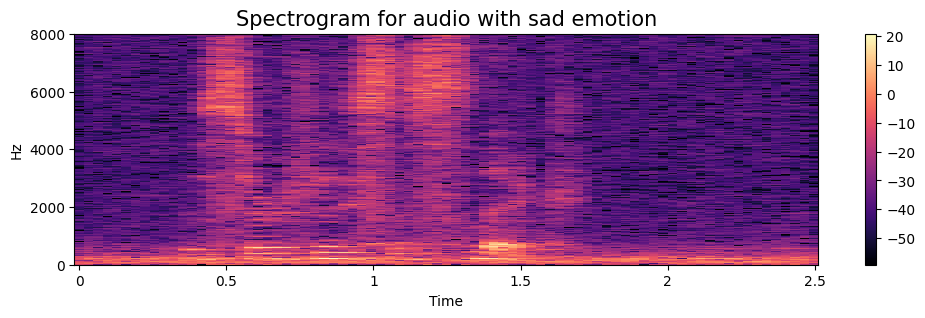

In [6]:
# Waveplot & audio spectrogram
def create_waveplot(data, sr, e):
    plt.figure(figsize=(12, 3))
    plt.title(f'Waveplot for audio with {e} emotion', size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid()
    plt.show()

def create_spectrogram(data, sr, e):
    X = librosa.stft(data) # short term fourier transform
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title(f'Spectrogram for audio with {e} emotion', size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
    plt.colorbar()

create_waveplot(y, sr, label1)
create_spectrogram(y, sr, label1)

In [7]:
# Audio signal preprocessing

# Peak normalisation
top_db=20
y_trimmed, index = librosa.effects.trim(y, top_db=top_db)
y_normz = y_trimmed / np.max(np.abs(y_trimmed))

# Zero padding - y_all
max_len = 80080
y_0pad = np.pad(y_normz, (0, max_len - len(y_normz)), mode='constant')
y_0pad_np = np.array(y_0pad)

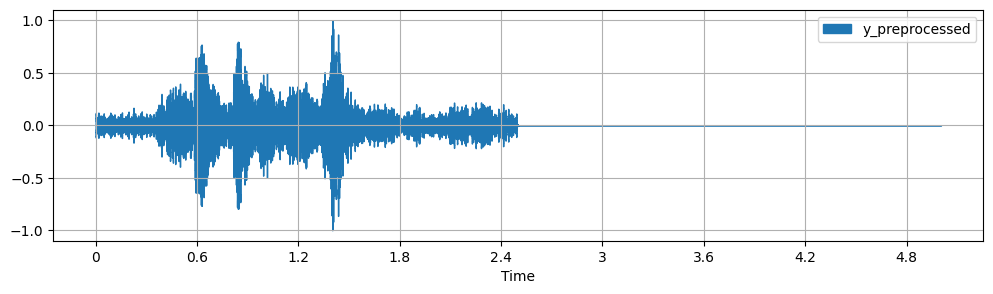

In [8]:
plt.figure(figsize=(12,3))
librosa.display.waveshow(y=y_0pad_np, sr=sr, label='y_preprocessed')
plt.grid()
plt.legend()
plt.show()

In [9]:
Audio(y_0pad_np, rate=sr)

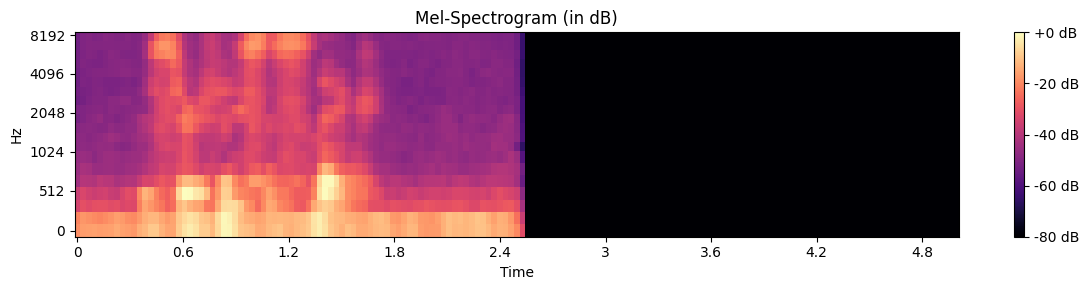



file: drive/My Drive/Speech Emotion Recognition/data/CREMA/1009_TSI_SAD_XX.wav, emotion: sad,
 original shape: (40040,), pre-processed shape:(80080,), sr: 16000


In [10]:
# Visualise the Mel Spectrogram

# Compute Mel Spectrogram
mel = librosa.feature.melspectrogram(y=y_0pad_np, sr=sr, n_mels=20)

# Convert to decibels
mel_db = librosa.power_to_db(mel, ref=np.max)

# Plot
plt.figure(figsize=(12, 3))
librosa.display.specshow(mel_db,
                         sr=sr,
                         x_axis='time',
                         y_axis='mel',
                         cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-Spectrogram (in dB)')
plt.tight_layout()
plt.show()

print(f"\n\nfile: {audio_path1}, emotion: {label1},\n original shape: {y.shape}, pre-processed shape:{y_0pad_np.shape}, sr: {sr}")

In [11]:
# Feature extraction
def entropy_of_energy(energy_frames, eps=1e-6):
    prob_energy = energy_frames / np.sum(energy_frames + eps)
    entropy = -np.sum(prob_energy * np.log2(prob_energy + eps))
    return entropy

def spectral_flux(S):
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2)) / S.shape[1]
    return flux

def FeatureExtraction2(data, sample_rate=16000):
    result = np.array([])

    # Zero Crossing Rate
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result = np.hstack((result, zcr))

    # RMS Energy
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms))

    # Entropy of Energy
    energy_frames = librosa.feature.rms(y=data).flatten()
    entropy = entropy_of_energy(energy_frames)
    result = np.hstack((result, entropy))

    # Chroma STFT (12)
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft))

    # MFCCs (13) + Delta (13) + Delta-Delta (13)
    mfcc = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=13)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    delta_mfcc = librosa.feature.delta(mfcc)
    delta_mfcc_mean = np.mean(delta_mfcc.T, axis=0)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    delta2_mfcc_mean = np.mean(delta2_mfcc.T, axis=0)
    result = np.hstack((result, mfcc_mean, delta_mfcc_mean, delta2_mfcc_mean))

    # Mel Spectrogram (20)
    mel = librosa.feature.melspectrogram(y=data, sr=sample_rate, n_mels=20)
    mel_mean = np.mean(mel.T, axis=0)
    result = np.hstack((result, mel_mean))

    # Spectral Centroid
    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, spec_centroid))

    # Spectral Rolloff
    spec_rolloff = np.mean(librosa.feature.spectral_rolloff(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, spec_rolloff))

    # Spectral Bandwidth
    spec_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, spec_bandwidth))

    # Spectral Contrast (7)
    spec_contrast = np.mean(librosa.feature.spectral_contrast(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, spec_contrast))

    # Spectral Flatness
    flatness = np.mean(librosa.feature.spectral_flatness(y=data).T, axis=0)
    result = np.hstack((result, flatness))

    # Spectral Flux
    S = librosa.stft(data)
    flux = spectral_flux(np.abs(S))
    result = np.hstack((result, flux))

    return result

features_y = np.array(FeatureExtraction2(y_0pad_np))
print(features_y.shape)

(86,)


In [12]:
from tensorflow.keras.models import load_model

scaler_save_path = 'drive/My Drive/Speech Emotion Recognition/models/ser_scaler.pkl'
model_save_path = 'drive/My Drive/Speech Emotion Recognition/models/ser_model.keras'
le_save_path = 'drive/My Drive/Speech Emotion Recognition/models/ser_labelencoder.pkl'

# Load the StandardScaler
with open(scaler_save_path, 'rb') as f:
    scaler = pickle.load(f)

# Load the model
model = load_model(model_save_path)

# Load the LabelEncoder
with open(le_save_path, 'rb') as f:
    le = pickle.load(f)

In [13]:
# Reshape to (1, 86) for a single sample transformation
features_scaled = scaler.transform(features_y.reshape(1, -1)) # Use transform, not fit_transform
print(features_scaled.shape)

# split the features to 3 groups for the model to learn different groups of features
temporal_idx = list(range(0, 3))    # zcr, rms, entropy
mfcc_idx = list(range(3, 42))       # mfcc + delta + delta2
spectral_idx = list(range(42, 86))  # spectral features

X_temporal = features_scaled[:, temporal_idx]  # shape: (1, 3)
X_mfcc     = features_scaled[:, mfcc_idx]      # shape: (1, 39)
X_spectral = features_scaled[:, spectral_idx]  # shape: (1, 44)

(1, 86)


In [14]:
# Predict
pred_probs = model.predict([X_temporal, X_mfcc, X_spectral])  # shape: (1, 4)
pred_class_index = np.argmax(pred_probs, axis=1)[0]           # scalar
pred_class_label = le.inverse_transform([pred_class_index])[0]
print(pred_class_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step
sad


In [15]:
print("Class Probabilities:", pred_probs[0])
print("Predicted Class Index:", pred_class_index)
print("Predicted Class Label:", pred_class_label)

Class Probabilities: [0.0036518  0.01232776 0.06662229 0.91739815]
Predicted Class Index: 3
Predicted Class Label: sad


In [16]:
print(f"Audio file         : {audio_path1}")

print(f"\nActual emotion     : {label1}")

ang = 100*float(pred_probs[0][0])
hap = 100*float(pred_probs[0][1])
neu = 100*float(pred_probs[0][2])
sad = 100*float(pred_probs[0][3])

print(f"SER's prediction   : {ang:.2f}% angry, {hap:.2f}% happy, {neu:.2f}% neutral, {sad:.2f}% sad, Dominant emotion: {pred_class_label}")

Audio file         : drive/My Drive/Speech Emotion Recognition/data/CREMA/1009_TSI_SAD_XX.wav

Actual emotion     : sad
SER's prediction   : 0.37% angry, 1.23% happy, 6.66% neutral, 91.74% sad, Dominant emotion: sad
